In [ ]:
# %% [markdown]
# # LiDAR feature EDA — usability & selection
# Decides which lidar__* features enter the future experiment.
# Two separate questions:
#   (1) PRESENCE: does crest_found (has a real crest) associate with grade?
#   (2) VALUE: among crest_found assets, does crest geometry associate with grade?
# Value analysis is restricted to each feature's own support (never fill nulls).
# Benchmarked against the project's null references: GeoSure |rho|<0.07, exposure null.


In [13]:

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from project_paths import paths

from sklearn.metrics import average_precision_score

from src.features import prepare_features

feats = pl.read_parquet(paths.processed_data / "lidar_features.parquet")
base = prepare_features(pl.read_parquet(paths.unified_file)).select(
    "asset_id", 
    "condition_grade",
    "actual_dcl", 
    "design_sop", 
    "age_years", 
    "asset_length_log1p",
    *[c for c in prepare_features(pl.read_parquet(paths.unified_file)).columns if c.startswith("geosure")],
)

df = base.join(feats, on="asset_id", how="left")


In [4]:

df


asset_id,condition_grade,actual_dcl,design_sop,age_years,asset_length_log1p,geosure_collapsible_deposits__class,geosure_compressible_ground__class,geosure_landslides__class,geosure_running_sand__class,geosure_shrink_swell__class,geosure_soluble_rocks__class,lidar__tier,lidar__n_stations,lidar__crest_offset_median,lidar__crest_prominence_median,lidar__crest_found,lidar__crest_relheight_mean,lidar__crest_relheight_min,lidar__crest_relheight_std,lidar__crest_width_mean,lidar__crest_resid_std,lidar__crest_resid_max_dip,lidar__crest_resid_ac1,lidar__crest_resid_tv_range
i64,i8,f64,f64,f64,f64,i8,i8,i8,i8,i8,i8,str,i64,f64,f64,bool,f64,f64,f64,f64,f64,f64,f64,f64
100006,3,94.129997,50.0,48.071184,4.39593,1,1,1,1,1,1,"""engineered_raised""",17,7.0,0.385002,true,1.977692,0.385498,0.461895,28.058824,0.164757,0.249674,-0.02079,4.07302
100010,3,98.050003,50.0,47.920602,4.696198,1,1,1,1,1,1,"""engineered_raised""",22,4.5,0.043999,false,null,null,null,null,null,null,null,null
100015,4,6.9299998,100.0,29.891855,5.80106,1,1,1,1,1,1,"""wall_like""",66,10.0,0.106,false,null,null,null,null,null,null,null,null
100016,3,9.6499996,100.0,29.891855,4.737951,1,1,1,1,1,1,"""wall_like""",23,10.0,0.0,false,null,null,null,null,null,null,null,null
100017,3,7.39,100.0,29.883641,4.746322,1,1,1,1,1,1,"""wall_like""",23,9.0,0.018,false,null,null,null,null,null,null,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
99960,3,4.14,30.0,60.358658,6.013984,1,1,1,1,2,1,"""engineered_raised""",82,3.5,1.3035,true,1.633754,0.14659,0.489809,32.695122,0.211414,0.669615,0.027874,8.054511
99963,3,6.3130002,5.0,80.596851,5.625749,1,1,1,1,1,1,"""engineered_raised""",56,2.0,1.24,true,1.958839,1.295,0.440354,40.785714,0.02994,0.071553,null,null
99966,3,7.79,40.0,42.475017,5.435772,1,3,2,1,2,2,"""engineered_raised""",46,2.0,1.152,true,1.858545,-0.0445,0.682942,34.847826,0.095853,0.273715,0.235569,7.233669


In [ ]:
# cgeck join one to one

print(df.height)
print(base.height)

23304
23304


In [6]:


LIDAR_NUM = [
    "lidar__crest_offset_median", 
    "lidar__crest_prominence_median",
    "lidar__crest_relheight_mean", 
    "lidar__crest_relheight_min", 
    "lidar__crest_relheight_std",
    "lidar__crest_width_mean", 
    "lidar__crest_resid_std", 
    "lidar__crest_resid_max_dip",
    "lidar__crest_resid_ac1", 
    "lidar__crest_resid_tv_range",
]


In [7]:

# The grade >= 4 coverage row is important
# coverage of lidar features specifically for assets grade 4 or 5 needs to be checked


n = df.height

found = df.filter(pl.col("lidar__crest_found"))

print(f"crest_found: {found.height}/{n} ({found.height/n:.1%})")
print(f" of all grade>=4 assets, crest_found: {df.filter(pl.col('condition_grade').is_in([4,5])).get_column('lidar__crest_found').mean():.1%}")
print(f"roughness populated (resid_ac1 non-null): {int(df['lidar__crest_resid_ac1'].is_not_null().sum())} ({df['lidar__crest_resid_ac1'].is_not_null().mean():.1%})\n")


crest_found: 11594/23304 (49.8%)
 of all grade>=4 assets, crest_found: 69.5%
roughness populated (resid_ac1 non-null): 5742 (24.6%)



In [9]:

tier_coverage = df.group_by("lidar__tier").agg(
    pl.len().alias("n"),
    pl.col("lidar__crest_found").mean().round(3).alias("crest_found_rate"),
    (pl.col("condition_grade") >= 4).mean().round(3).alias("grade_ge4_rate"),
    pl.col("lidar__crest_prominence_median").is_not_null().mean().round(3).alias("has_prominence"),
).sort("n", descending=True)

tier_coverage


lidar__tier,n,crest_found_rate,grade_ge4_rate,has_prominence
str,u32,f64,f64,f64
"""engineered_raised""",14585,0.79,0.122,1.0
"""wall_like""",4912,0.0,0.063,1.0
null,3566,0.0,0.038,0.0
"""natural_geomorphic""",161,0.472,0.075,1.0
"""point""",80,0.0,0.05,1.0


In [10]:

# does crest_found alone track grade?
# if crest_found associates with grade, the feature's presence carries information (rather than or as well as its value)
# signal could be independent of any geometry value

presence = df.group_by("lidar__crest_found").agg(
    pl.len().alias("n"),
    (pl.col("condition_grade") >= 4).mean().round(4).alias("p_grade_ge4"),
    pl.col("condition_grade").mean().round(3).alias("mean_grade"),
).sort("lidar__crest_found")

presence


lidar__crest_found,n,p_grade_ge4,mean_grade
bool,u32,f64,f64
false,11710,0.0583,2.633
true,11594,0.1344,2.959


i think this looks like the precence, i.e. any not null value of the crest, will carry a predictive signal that the grade should be a higher grade. This could make it unfair to include if we think the coverage is random, or it could genuinely be a signal about the type of or location of asset that is fair to include

In [11]:


m = df.select("lidar__crest_found", "condition_grade").drop_nulls()
rho_pres, p_pres = spearmanr(
    m.get_column("lidar__crest_found").cast(pl.Int8).to_numpy(),
    m.get_column("condition_grade").to_numpy()
)

print(f"\ncrest_found vs grade: rho={rho_pres:+.3f}  p={p_pres:.2e}")



crest_found vs grade: rho=+0.248  p=0.00e+00


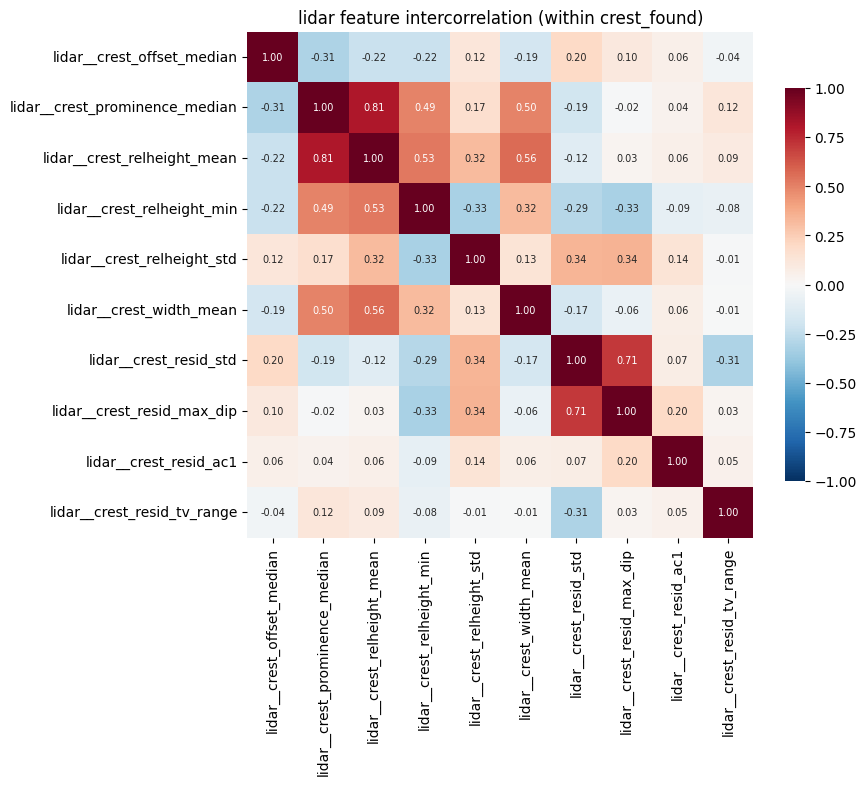

In [14]:

# check for high correlation among lidar features so that features with redundant duplicate signal can be dropped
import seaborn as sns
from scipy.stats import spearmanr

sub = found.select(LIDAR_NUM)
present = [c for c in LIDAR_NUM if sub[c].is_not_null().any()]
mat = sub.select(present).drop_nulls().to_numpy()
corr, _ = spearmanr(mat)
corr = np.atleast_2d(corr)
labels = [c.replace("lidar_crest_", "") for c in present]

fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(
    corr, 
    annot=True, 
    fmt=".2f", 
    cmap="RdBu_r", 
    vmin=-1, 
    vmax=1,
    xticklabels=labels, 
    yticklabels=labels, 
    square=True,
    annot_kws={"fontsize": 7}, 
    cbar_kws={"shrink": 0.7}, 
    ax=ax
)

ax.set_title("lidar feature intercorrelation (within crest_found)")
plt.tight_layout()
plt.show()


In [15]:


# check for redundancy vs existing aims features
# question is, is lidar relheight/prominence just reencoding actual_dcl or length?
# (memory - absolute crest elevation is redundant with actual_dcl, relative height should not be)

cross = found.select(
    "lidar__crest_relheight_mean", 
    "lidar__crest_prominence_median", 
    "lidar__crest_width_mean",
    "actual_dcl", 
    "design_sop", 
    "age_years", 
    "asset_length_log1p",
).drop_nulls()

cm, _ = spearmanr(cross.to_numpy())
cols = cross.columns
li, ai = [c for c in cols if c.startswith("lidar")], [c for c in cols if not c.startswith("lidar")]
block = np.array([[cm[cols.index(l), cols.index(a)] for a in ai] for l in li])

print(
    pl.DataFrame({"lidar_feature": li, **{a: [round(float(block[r, c]), 3) for r in range(len(li))] for c, a in enumerate(ai)}})
)


shape: (3, 5)
┌────────────────────────────────┬────────────┬────────────┬───────────┬────────────────────┐
│ lidar_feature                  ┆ actual_dcl ┆ design_sop ┆ age_years ┆ asset_length_log1p │
│ ---                            ┆ ---        ┆ ---        ┆ ---       ┆ ---                │
│ str                            ┆ f64        ┆ f64        ┆ f64       ┆ f64                │
╞════════════════════════════════╪════════════╪════════════╪═══════════╪════════════════════╡
│ lidar__crest_relheight_mean    ┆ -0.211     ┆ 0.285      ┆ 0.098     ┆ 0.191              │
│ lidar__crest_prominence_median ┆ -0.258     ┆ 0.241      ┆ 0.098     ┆ 0.255              │
│ lidar__crest_width_mean        ┆ -0.091     ┆ 0.177      ┆ 0.069     ┆ 0.205              │
└────────────────────────────────┴────────────┴────────────┴───────────┴────────────────────┘


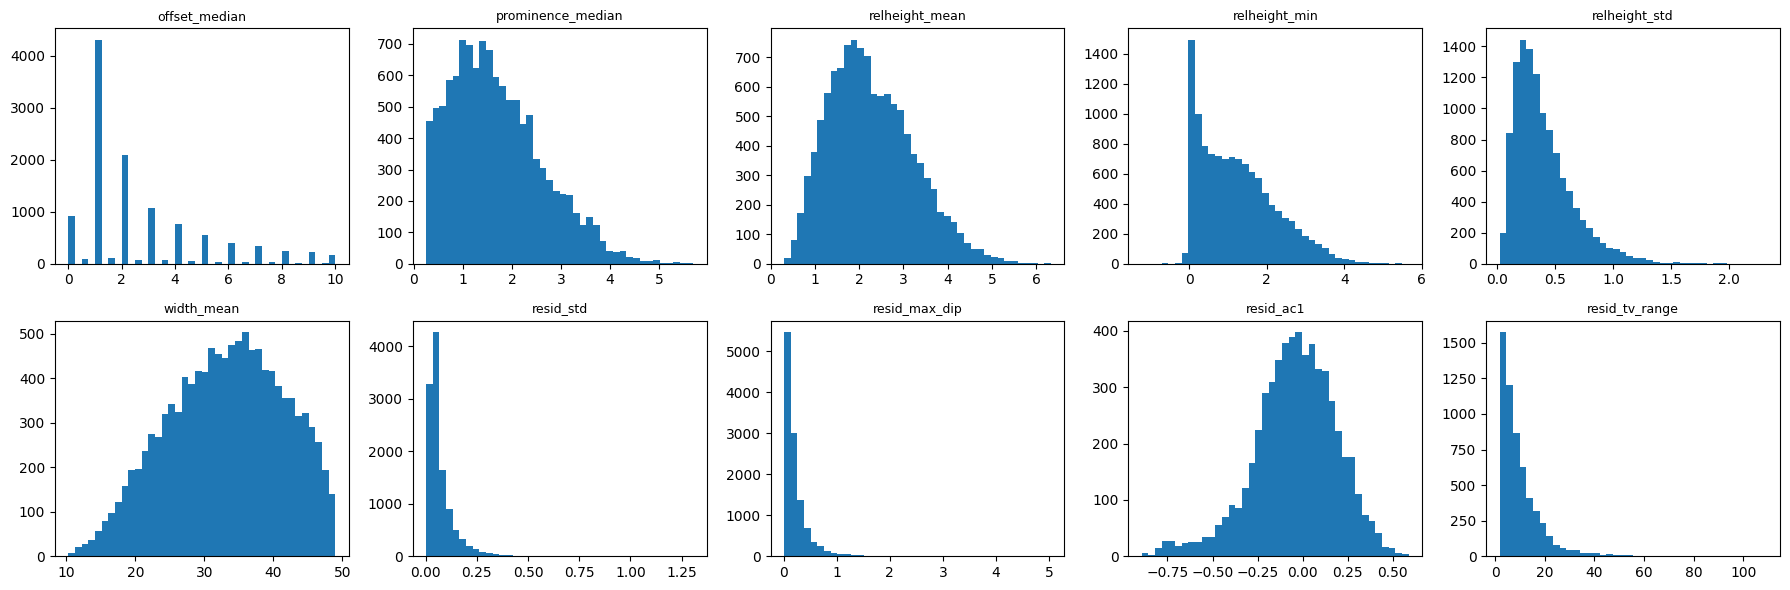

In [16]:

fig, axes = plt.subplots(2, 5, figsize=(18, 6))
for ax, c in zip(axes.ravel(), LIDAR_NUM):
    v = found[c].drop_nulls().to_numpy()
    if v.size:
        ax.hist(v, bins=40); ax.set_title(c.replace("lidar__crest_", ""), fontsize=9)
plt.tight_layout(); plt.show()


In [18]:

# look at relationship to target variable (grade)
# corr with grade + bootstrap confidence interval
# will copy my stats r notes and see if i can transfer to python

def target_stats(frame, feat, n_boot=1000, seed=0):

    s = frame.select(feat, "condition_grade").drop_nulls()
    x = s[feat].to_numpy()
    y = s["condition_grade"].to_numpy()

    if len(x) < 30 or np.unique(x).size < 3:
        return None
    
    rho = spearmanr(x, y).statistic

    ybin = (y >= 4).astype(int)
    prev = float(ybin.mean())

    # avg_precision = average_precision_score(ybin, x * (np.sign(rho)))

    avg_precision = (
        average_precision_score(ybin, x * (np.sign(rho) or 1.0))
        if 0 < ybin.sum() < len(ybin) else float("nan")
    )

    rng = np.random.default_rng(seed)
    boot = np.array(
        [spearmanr(x[i], y[i]).statistic for i in (rng.integers(0, len(x), len(x)) for _ in range(n_boot))]
    )

    low, high = np.nanpercentile(boot, [2.5, 97.5])

    result = {
        "feature": feat.replace("lidar__crest_", ""),
        "n": len(x),
        "rho": round(rho, 4),
        "rho_low": round(low, 4),
        "rho_high": round(high, 4),
        "average_precision": round(avg_precision, 5),
        "previous": round(prev, 5),
        "average_precision_increase": (round(avg_precision / prev, 4) if prev else None),
        "confidence_int_exludes_0": (low > 0 or high < 0)
    }

    return result

stats = [target_stats(df, column) for column in LIDAR_NUM]

stats


[{'feature': 'offset_median',
  'n': 19738,
  'rho': np.float64(-0.0821),
  'rho_low': np.float64(-0.0955),
  'rho_high': np.float64(-0.067),
  'average_precision': 0.12829,
  'previous': 0.10675,
  'average_precision_increase': 1.2018,
  'confidence_int_exludes_0': np.True_},
 {'feature': 'prominence_median',
  'n': 19738,
  'rho': np.float64(0.1244),
  'rho_low': np.float64(0.1107),
  'rho_high': np.float64(0.1382),
  'average_precision': 0.13075,
  'previous': 0.10675,
  'average_precision_increase': 1.2248,
  'confidence_int_exludes_0': np.True_},
 {'feature': 'relheight_mean',
  'n': 11594,
  'rho': np.float64(0.0318),
  'rho_low': np.float64(0.0146),
  'rho_high': np.float64(0.0495),
  'average_precision': 0.13756,
  'previous': 0.13438,
  'average_precision_increase': 1.0236,
  'confidence_int_exludes_0': np.True_},
 {'feature': 'relheight_min',
  'n': 11594,
  'rho': np.float64(-0.0001),
  'rho_low': np.float64(-0.0169),
  'rho_high': np.float64(0.0181),
  'average_precision': 

In [19]:
stats_df = pl.DataFrame(stats)

stats_df

feature,n,rho,rho_low,rho_high,average_precision,previous,average_precision_increase,confidence_int_exludes_0
str,i64,f64,f64,f64,f64,f64,f64,f64
"""offset_median""",19738,-0.0821,-0.0955,-0.067,0.12829,0.10675,1.2018,1.0
"""prominence_median""",19738,0.1244,0.1107,0.1382,0.13075,0.10675,1.2248,1.0
"""relheight_mean""",11594,0.0318,0.0146,0.0495,0.13756,0.13438,1.0236,1.0
"""relheight_min""",11594,-0.0001,-0.0169,0.0181,0.14019,0.13438,1.0433,0.0
"""relheight_std""",11594,0.0027,-0.0159,0.0209,0.14163,0.13438,1.0539,0.0
"""width_mean""",11594,-0.0431,-0.0617,-0.0254,0.13845,0.13438,1.0303,1.0
"""resid_std""",11594,0.0977,0.0807,0.117,0.15259,0.13438,1.1355,1.0
"""resid_max_dip""",11594,0.1114,0.0947,0.1301,0.16583,0.13438,1.234,1.0
"""resid_ac1""",5742,-0.0146,-0.0409,0.0118,0.1566,0.16022,0.9774,0.0


In [20]:
stats_df.sort(pl.col("rho").abs(), descending=True)

feature,n,rho,rho_low,rho_high,average_precision,previous,average_precision_increase,confidence_int_exludes_0
str,i64,f64,f64,f64,f64,f64,f64,f64
"""resid_tv_range""",5742,0.1746,0.1492,0.1987,0.23106,0.16022,1.4421,1.0
"""prominence_median""",19738,0.1244,0.1107,0.1382,0.13075,0.10675,1.2248,1.0
"""resid_max_dip""",11594,0.1114,0.0947,0.1301,0.16583,0.13438,1.234,1.0
"""resid_std""",11594,0.0977,0.0807,0.117,0.15259,0.13438,1.1355,1.0
"""offset_median""",19738,-0.0821,-0.0955,-0.067,0.12829,0.10675,1.2018,1.0
"""width_mean""",11594,-0.0431,-0.0617,-0.0254,0.13845,0.13438,1.0303,1.0
"""relheight_mean""",11594,0.0318,0.0146,0.0495,0.13756,0.13438,1.0236,1.0
"""resid_ac1""",5742,-0.0146,-0.0409,0.0118,0.1566,0.16022,0.9774,0.0
"""relheight_std""",11594,0.0027,-0.0159,0.0209,0.14163,0.13438,1.0539,0.0


In [22]:
# repeat test, splitting into groups of defense subtypes


eng = df.filter(pl.col("lidar__tier") == "engineered_raised")
eng_stats = [target_stats(eng, column) for column in LIDAR_NUM]
eng_stats_df = pl.DataFrame(eng_stats)

eng_stats_df.sort(pl.col("rho").abs(), descending=True)


feature,n,rho,rho_low,rho_high,average_precision,previous,average_precision_increase,confidence_int_exludes_0
str,i64,f64,f64,f64,f64,f64,f64,f64
"""resid_tv_range""",5675,0.186,0.1615,0.2103,0.23392,0.16141,1.4492,1.0
"""resid_max_dip""",11518,0.1171,0.0986,0.1365,0.16769,0.13492,1.2429,1.0
"""resid_std""",11518,0.1037,0.0863,0.1222,0.1543,0.13492,1.1437,1.0
"""width_mean""",11518,-0.047,-0.0637,-0.0294,0.13939,0.13492,1.0332,1.0
"""prominence_median""",14585,0.042,0.0268,0.0577,0.13905,0.12204,1.1393,1.0
"""relheight_mean""",11518,0.029,0.0118,0.0479,0.13795,0.13492,1.0225,1.0
"""offset_median""",14585,-0.0211,-0.037,-0.0064,0.13941,0.12204,1.1423,1.0
"""resid_ac1""",5675,-0.0111,-0.0353,0.0162,0.15694,0.16141,0.9723,0.0
"""relheight_std""",11518,0.0075,-0.0101,0.0247,0.14301,0.13492,1.06,0.0


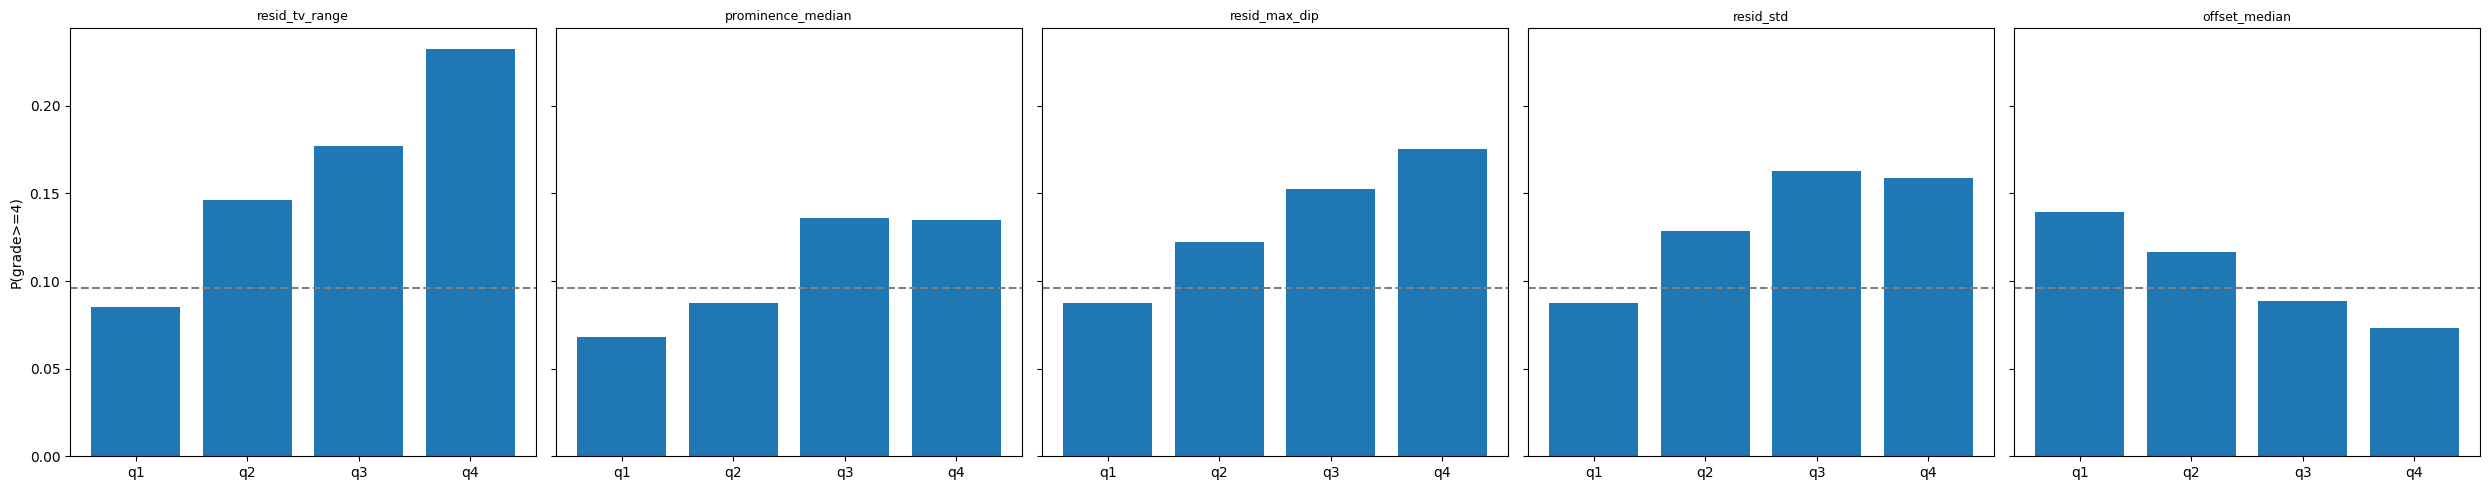

In [35]:

# grade>=4 prevalence by quartile 


top = stats_df.sort(pl.col("rho").abs(), descending=True).head()["feature"].to_list()

fig, axes = plt.subplots(1, 5, figsize=(25, 5), sharey=True)

for ax, name in zip(np.atleast_1d(axes), top):

    col = f"lidar__crest_{name}"
    series = df.select(col, "condition_grade").drop_nulls()
    quartiles = series.with_columns(pl.col(col).qcut(4, labels=["q1", "q2", "q3", "q4"], allow_duplicates=True).alias("q"))
    # print(quartiles)

    prev = quartiles.group_by("q").agg((pl.col("condition_grade") >= 4).mean().alias("p")).sort("q")
    # print(prev)

    ax.bar(prev["q"].to_list(), prev["p"].to_list())

    # thing = df.select(pl.col("condition_grade").ge(4).cast(pl.Int8)).mean()
    # print(thing)

    ax.axhline(
        df.select(pl.col("condition_grade").ge(4).cast(pl.Int8)).mean().item(), 
        ls="--", 
        c="grey"
    )

    ax.set_title(name, fontsize=9)


axes[0].set_ylabel("P(grade>=4)") if np.ndim(axes) else axes.set_ylabel("P(grade>=4)")
plt.tight_layout(); plt.show()


In [ ]:

# benchmark against the other features already explored and found to be unimportant

geo = [c for c in df.columns if c.startswith("geosure")]
geo_rho = []

for c in geo:
    s = df.select(c, "condition_grade").drop_nulls()
    if s.height > 30:
        geo_rho.append(abs(spearmanr(s[c].to_numpy(), s["condition_grade"].to_numpy()).statistic))

print(f"GeoSure absolute rho (null ref): max {max(geo_rho):.3f}, mean {np.mean(geo_rho):.3f}")
print(f"crest_found presence absolute rho: {abs(rho_pres):.3f}")
print(f"best lidar value absolute rho: {stats_df['rho'].abs().max():.3f}")


GeoSure absolute rho (null ref): max 0.086, mean 0.056
crest_found presence absolute rho: 0.248
best lidar value absolute rho: 0.175


numbers found so far are promising if suprising.

the signal we have found is good, but its whether or not the crest can be detected at all, and the actual geometry of what we find is much less important.
This is interesting, but I think it could jsut be reencoding other information about the type/design/location. For example, all of the flood defenses assigned a point geometry and have no crest detected. So crest detected contains some information that is just "is this an embankment or a flood gate?", and this will just be a duplicate of the predictive power we already have in the asset subtype (got decent SHAP scores in experiments so far). 

In [40]:
eng = df.filter(pl.col("lidar__tier") == "engineered_raised")
eng.group_by("lidar__crest_found").agg(
    pl.len().alias("n"),
    (pl.col("condition_grade") >= 4).mean().round(4).alias("p_ge4"),
)


lidar__crest_found,n,p_ge4
bool,u32,f64
false,3067,0.0737
true,11518,0.1349


In [41]:

m = eng.select("lidar__crest_found","condition_grade").drop_nulls()
print(spearmanr(m["lidar__crest_found"].cast(pl.Int8), m["condition_grade"]))

SignificanceResult(statistic=np.float64(0.040859144885410724), pvalue=np.float64(7.968770013861472e-07))


In [42]:
walls = df.filter(pl.col("lidar__tier") == "engineered_raised")
walls.group_by("lidar__crest_found").agg(
    pl.len().alias("n"),
    (pl.col("condition_grade") >= 4).mean().round(4).alias("p_ge4"),
)


lidar__crest_found,n,p_ge4
bool,u32,f64
false,3067,0.0737
true,11518,0.1349


In [43]:

m = walls.select("lidar__crest_found","condition_grade").drop_nulls()
print(spearmanr(m["lidar__crest_found"].cast(pl.Int8), m["condition_grade"]))

SignificanceResult(statistic=np.float64(0.040859144885410724), pvalue=np.float64(7.968770013861472e-07))


i think this confirms the hunch, there is basically no relationship between the presence and the target feature within subtypes. So it was just reencoding the subtype information. Since asset subtype is already a feature that will be included, i think the crest found feature will be excluded

this leaves the other geometry based features that do carry some signal: prominance median, resid max dip, and maybe resid standard dev and resid tv max. This is somewhat gratifying - these are the features that i spent time adding while the basic features that were easy to add first like relative height don't carry enough signal to be included. 

tv max has coverage on only a low number of assets

In [44]:
sh = df.filter(pl.col("lidar__crest_resid_tv_range").is_not_null()).select(
    "lidar__crest_resid_std", "lidar__crest_resid_tv_range", "lidar__crest_resid_max_dip", "condition_grade"
).drop_nulls()



In [46]:


print(
      spearmanr(sh["lidar__crest_resid_std"], sh["lidar__crest_resid_tv_range"])
)

for c in ["lidar__crest_resid_std", "lidar__crest_resid_tv_range", "lidar__crest_resid_max_dip"]:
      print(c, round(spearmanr(sh[c], sh["condition_grade"]).statistic, 3))

SignificanceResult(statistic=np.float64(-0.30822468440383183), pvalue=np.float64(1.2909811259799857e-126))
lidar__crest_resid_std -0.019
lidar__crest_resid_tv_range 0.175
lidar__crest_resid_max_dip 0.034


this is the opposite of what i was expecting - i thought that when all three are compared, tv max may drop out because the signal is carried by the other two features already. The finding it the opposite, tv range has the highest value and standard dev and max dip fall much closer to 0. 


so updated outcome:
    definitely keep tv_range and prominance_median
    maybe keep resid_max_dip and resid_std

no interaction effects have been tested. So its worth carrying forward more features rather than fewer and seeing if the combinations actually improve a real model or not. 